In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import contextily as ctx
import pandas as pd


pd.set_option('display.max_columns', 500)

In [2]:
with open('gdf_ht.pickle', 'rb') as file:
    gdf_ht =  pickle.load(file)

In [3]:
with open('warsaw.pickle', 'rb') as file:
    warsaw =  pickle.load(file)

In [4]:
with open('powiaty_maz.pickle', 'rb') as file:
    powiaty_maz =  pickle.load(file)

In [5]:
with open('dzielnice.pickle', 'rb') as file:
    dzielnice =  pickle.load(file)

In [6]:
with open('gdf.pickle', 'rb') as file:
    gdf =  pickle.load(file)

In [7]:
pkd7 = pd.read_excel('C:\\Studia\\Master\\master_thesis\\data\\PKD7_HT.xlsx')

In [8]:
pkd7

,PKD7,Group
0,0111Z,O
1,0112Z,O
2,0113Z,O
3,0114Z,O
4,0115Z,O
...,...,...
649,9609Z,O
650,9700Z,O
651,9810Z,O
652,9820Z,O


In [9]:
gdf = pd.merge(gdf, pkd7, on='PKD7', how='left')

In [10]:
gdf

,?,ID,REGON,POWIAT,GMINA,Address_full,SEK_PKD7,PKD7,GR_LPRAC,lon,lat,tech,if_hightech,empl,sharesEMPL2,ones,locPdens,locAggA,locAggB,locAggC,locAggD,locAggE,locAggF,locAggG,locAggH,locAggI,locAggJ,locAggK,locAggL,locAggM,locAggN,locAggO,locAggP,locAggQ,locAggR,locAggS,locAggT,locAggU,locHH,locBIG,locAggTOTAL,locHightech,locLQ,dist_core_10,dist_core_25,dist_core_50,dist_midsize_10,dist_midsize_25,dist_midsize_50,dist_regional_10,dist_regional_25,dist_regional_50,dist_localbig_10,dist_localbig_25,dist_localbig_50,dist_localsmall_10,dist_localsmall_25,dist_localsmall_50,COREfirms,COREpopul,geometry,Group
0,42342,1,1.406805e+13,17,44,Joachima Lelewela 27 05-480 Karczew,S,9499Z,1,21.23600,52.08347,NaN,0,5.034085,1.856614e-10,1,26,18,0,38,0,1,25,56,13,1,7,5,1,11,5,0,6,9,1,8,0,0,1.468536e-09,0,205,15,0.851179,0,1,1,0,0,0,0,0,1,1,1,1,0,1,1,1,1,POINT (21.23600 52.08347),O
1,42343,2,6.721748e+13,7,22,Rogożek 3 26-903 Rogożek,A,0150Z,1,21.36008,51.63636,NaN,0,5.035107,1.531587e-11,1,1,2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.994063e-11,0,3,0,2.586889,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,POINT (21.36008 51.63636),O
2,118240,3,1.109380e+12,65,58,Ignacego Krasickiego 12A 02-611 Warszawa,G,4690Z,1,21.02140,52.19191,NaN,0,5.001276,1.518227e-11,1,203,72,4,141,24,12,192,620,111,64,203,98,185,533,121,0,89,101,51,207,0,1,2.685278e-07,34,2829,183,1.126141,1,1,1,0,0,0,0,1,1,0,1,1,1,1,1,1,1,POINT (21.02140 52.19191),O
3,210007,4,1.566525e+12,65,188,al. Prymasa Tysiąclecia 62 01-424 Warszawa,G,4643Z,1,20.95726,52.23474,NaN,0,5.114140,1.587524e-11,1,220,10,1,35,3,4,47,133,25,27,42,19,54,111,29,3,25,24,12,38,0,0,3.089481e-08,6,642,49,1.064512,1,1,1,0,0,0,0,1,1,0,1,1,0,1,1,1,1,POINT (20.95726 52.23474),O
4,423467,5,1.401995e+13,65,48,Marymoncka 93/97 01-813 Warszawa,S,9511Z,1,20.95403,52.28521,NaN,0,4.939015,1.787151e-10,1,150,50,0,172,2,2,166,505,110,59,143,66,105,323,104,1,106,111,69,164,0,0,5.495024e-07,16,2258,141,1.584181,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,POINT (20.95403 52.28521),MLT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
983714,848910,983715,6.700468e+13,63,11,Adama Mickiewicza 15A 26-600 Radom,K,6492Z,1,21.15541,51.39728,NaN,0,5.051210,5.576468e-10,1,171,304,5,450,4,12,397,1713,286,167,114,192,335,570,118,11,229,350,84,421,0,0,6.346276e-07,59,5762,157,1.332165,0,0,0,0,1,1,0,0,0,0,0,0,0,1,1,1,1,POINT (21.15541 51.39728),KIS
983715,948039,983716,1.403177e+13,65,108,Złota 59 00-120 Warszawa,F,4110Z,1,21.00245,52.23008,NaN,0,5.046067,9.670373e-11,1,197,115,21,417,106,25,608,1593,209,278,573,646,709,1843,315,13,132,172,110,587,0,6,2.378078e-06,116,8478,594,0.985588,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,POINT (21.00245 52.23008),O
983716,937486,983717,1.662122e+12,65,168,Arbuzowa 45 02-747 Warszawa,A,0150Z,1,21.06074,52.16853,NaN,0,4.993093,1.506134e-11,1,91,66,4,110,4,2,127,350,83,26,179,79,77,366,70,0,79,90,48,115,0,2,9.951653e-10,6,1877,181,0.136442,1,1,1,0,0,0,0,0,1,0,1,1,1,1,1,1,1,POINT (21.06074 52.16853),O
983717,907962,983718,2.041457e+11,65,118,Rusiecka 10 03-698 Warszawa,C,1812Z,1,21.07733,52.29214,NaN,0,5.006657,5.524592e-11,1,48,21,1,111,0,0,95,304,80,27,80,34,36,140,48,1,39,39,17,66,0,0,7.687505e-08,5,1139,87,1.629730,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,POINT (21.07733 52.29214),LT


In [11]:
gdf['tech'].fillna('other', inplace=True)

C:\Users\Filip\AppData\Local\Temp\ipykernel_10372\1097909830.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  gdf['tech'].fillna('other', inplace=True)


In [12]:
gdf['Group'].value_counts()

Group
O        718731
KIS      131016
HTKIS     56774
MLT       37023
LT        30192
MHT        5862
HT         2173
PMHT       1944
Name: count, dtype: int64

In [13]:
one_hot_encoded = pd.get_dummies(gdf['Group'])

# Convert boolean values to integers (0 and 1)
one_hot_encoded = one_hot_encoded.astype(int)

# Concatenate the original DataFrame with the one-hot encoded DataFrame
df_encoded = pd.concat([gdf, one_hot_encoded], axis=1)

df_encoded.head()

,?,ID,REGON,POWIAT,GMINA,Address_full,SEK_PKD7,PKD7,GR_LPRAC,lon,lat,tech,if_hightech,empl,sharesEMPL2,ones,locPdens,locAggA,locAggB,locAggC,locAggD,locAggE,locAggF,locAggG,locAggH,locAggI,locAggJ,locAggK,locAggL,locAggM,locAggN,locAggO,locAggP,locAggQ,locAggR,locAggS,locAggT,locAggU,locHH,locBIG,locAggTOTAL,locHightech,locLQ,dist_core_10,dist_core_25,dist_core_50,dist_midsize_10,dist_midsize_25,dist_midsize_50,dist_regional_10,dist_regional_25,dist_regional_50,dist_localbig_10,dist_localbig_25,dist_localbig_50,dist_localsmall_10,dist_localsmall_25,dist_localsmall_50,COREfirms,COREpopul,geometry,Group,HT,HTKIS,KIS,LT,MHT,MLT,O,PMHT
0,42342,1,1.406805e+13,17,44,Joachima Lelewela 27 05-480 Karczew,S,9499Z,1,21.23600,52.08347,other,0,5.034085,1.856614e-10,1,26,18,0,38,0,1,25,56,13,1,7,5,1,11,5,0,6,9,1,8,0,0,1.468536e-09,0,205,15,0.851179,0,1,1,0,0,0,0,0,1,1,1,1,0,1,1,1,1,POINT (21.23600 52.08347),O,0,0,0,0,0,0,1,0
1,42343,2,6.721748e+13,7,22,Rogożek 3 26-903 Rogożek,A,0150Z,1,21.36008,51.63636,other,0,5.035107,1.531587e-11,1,1,2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.994063e-11,0,3,0,2.586889,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,POINT (21.36008 51.63636),O,0,0,0,0,0,0,1,0
2,118240,3,1.109380e+12,65,58,Ignacego Krasickiego 12A 02-611 Warszawa,G,4690Z,1,21.02140,52.19191,other,0,5.001276,1.518227e-11,1,203,72,4,141,24,12,192,620,111,64,203,98,185,533,121,0,89,101,51,207,0,1,2.685278e-07,34,2829,183,1.126141,1,1,1,0,0,0,0,1,1,0,1,1,1,1,1,1,1,POINT (21.02140 52.19191),O,0,0,0,0,0,0,1,0
3,210007,4,1.566525e+12,65,188,al. Prymasa Tysiąclecia 62 01-424 Warszawa,G,4643Z,1,20.95726,52.23474,other,0,5.114140,1.587524e-11,1,220,10,1,35,3,4,47,133,25,27,42,19,54,111,29,3,25,24,12,38,0,0,3.089481e-08,6,642,49,1.064512,1,1,1,0,0,0,0,1,1,0,1,1,0,1,1,1,1,POINT (20.95726 52.23474),O,0,0,0,0,0,0,1,0
4,423467,5,1.401995e+13,65,48,Marymoncka 93/97 01-813 Warszawa,S,9511Z,1,20.95403,52.28521,other,0,4.939015,1.787151e-10,1,150,50,0,172,2,2,166,505,110,59,143,66,105,323,104,1,106,111,69,164,0,0,5.495024e-07,16,2258,141,1.584181,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,POINT (20.95403 52.28521),MLT,0,0,0,0,0,1,0,0


if_hightech = high-tech, medium high-tech, knowledge intensive

In [14]:
warsaw_ht = warsaw[warsaw['if_hightech'] == 1]

In [15]:
import math

lon = 21.017532
lat = 52.237049


one_km_in_degrees_lat = 5 / 111.32
one_km_in_degrees_lon = 5 / (111.32 * math.cos(math.radians(lat)))

grid_size = min(one_km_in_degrees_lat, one_km_in_degrees_lon)

print("Grid Size for Approximately 1 km Grid:", grid_size, "degrees")

average_grid_size = (one_km_in_degrees_lat + one_km_in_degrees_lon) / 2

print("Average Grid Size for Approximately 1 km Grid:", average_grid_size, "degrees")


Grid Size for Approximately 1 km Grid: 0.044915558749550846 degrees
Average Grid Size for Approximately 1 km Grid: 0.0591297689745963 degrees


In [16]:
gdf_ht = gdf[gdf['if_hightech'] == 1]

c:\Users\Filip\AppData\Local\Programs\Python\Python312\Lib\site-packages\geopandas\geodataframe.py:1525: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\Filip\AppData\Local\Programs\Python\Python312\Lib\site-packages\geopandas\geodataframe.py:1525: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


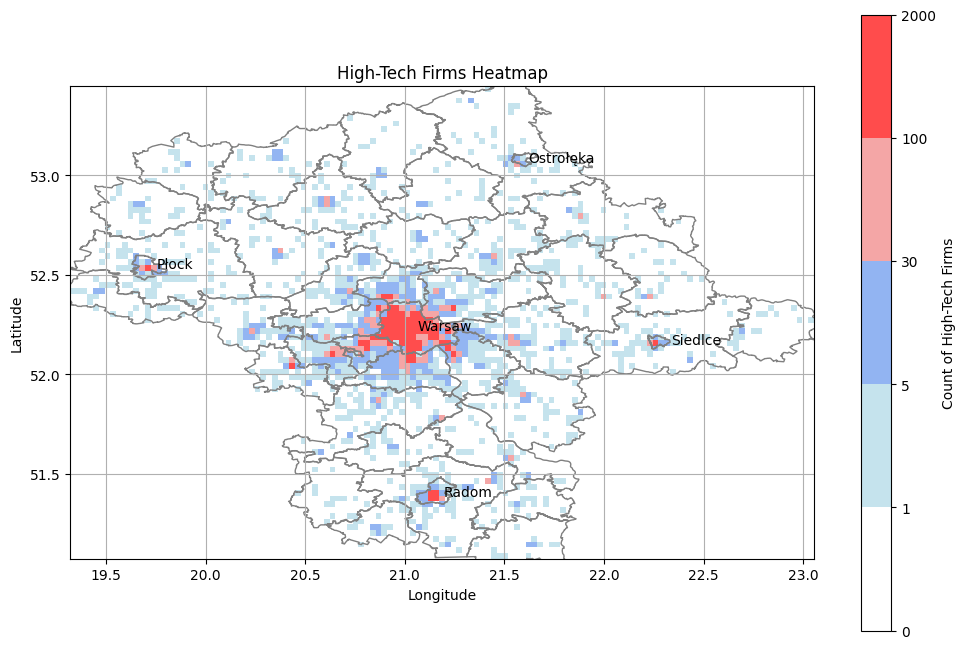

In [17]:
min_lon_maz, max_lon_maz = gdf_ht['lon'].min(), gdf_ht['lon'].max()
min_lat_maz, max_lat_maz = gdf_ht['lat'].min(), gdf_ht['lat'].max()
grid_size = 0.02912

lons_maz = np.arange(min_lon_maz, max_lon_maz, grid_size)
lats_maz = np.arange(min_lat_maz, max_lat_maz, grid_size)

gdf_ht['grid_x_maz_ht'] = np.digitize(gdf_ht['lon'], lons_maz)
gdf_ht['grid_y_maz_ht'] = np.digitize(gdf_ht['lat'], lats_maz)

grid_counts_maz = gdf_ht.groupby(['grid_x_maz_ht', 'grid_y_maz_ht']).size().reset_index(name='firm_count_maz_ht')
gdf_ht = gdf_ht.merge(grid_counts_maz, how='left', on=['grid_x_maz_ht', 'grid_y_maz_ht'])

heatmap_maz = np.zeros((len(lats_maz), len(lons_maz)))

for idx, row in grid_counts_maz.iterrows():
    grid_x, grid_y = row['grid_x_maz_ht'] - 1, row['grid_y_maz_ht'] - 1  
    count = row['firm_count_maz_ht']
    heatmap_maz[grid_y, grid_x] = count


city_lon = [21.017532, 21.14714, 19.70638, 22.29006, 21.5714]
city_lat = [52.237049, 51.40253, 52.54682, 52.16772, 53.0813]
city_names = ['Warsaw', 'Radom', 'Płock', 'Siedlce', 'Ostrołęka']

colors = ['white', 'lightblue', 'cornflowerblue', 'lightcoral', 'red']
bounds = [0, 1, 5, 30, 100, 2000]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, len(colors))

ax = powiaty_maz.plot(figsize=(12, 8), color='none', edgecolor='grey')

plt.imshow(heatmap_maz, cmap=cmap, norm=norm, origin='lower', extent=[min_lon_maz, max_lon_maz, min_lat_maz, max_lat_maz], alpha=0.7)

for city, lon, lat in zip(city_names, city_lon, city_lat):
    plt.annotate(city, xy=(lon, lat), xytext=(7, -2), textcoords='offset points', color='black', fontsize=10)

plt.colorbar(label='Count of High-Tech Firms')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('High-Tech Firms Heatmap')

plt.grid(True)
plt.show()


Radius 500m maz

In [ ]:
import geopandas as gpd
from shapely.geometry import Point

radius =  0.00734 
gdf_ht['buffer'] = gdf_ht.geometry.buffer(radius)

target_variable = []

for index, location in gdf_ht.iterrows():
    high_tech_firms_within_radius = gdf_ht[gdf_ht.geometry.within(location['buffer'])]
    num_high_tech_firms = len(high_tech_firms_within_radius)
    target_variable.append(num_high_tech_firms)

gdf_ht['high_tech_firm_clustering'] = target_variable


In [ ]:
gdf_ht

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Polygon
from mpl_toolkits.axes_grid1 import make_axes_locatable  # Import this module for colorbar

# Define colors for the clustering levels
colors = ['white', 'lightblue', 'cornflowerblue', 'lightcoral', 'red']
bounds = [0, 1, 3, 7, 15, 50]
cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, len(colors))

# Plot the administrative boundaries
fig, ax = plt.subplots(figsize=(12, 8))
powiaty_maz.plot(ax=ax, color='none', edgecolor='grey')

# Overlay the heatmap of high-tech firm clustering
gdf_ht.plot(ax=ax, column='high_tech_firm_clustering', cmap=cmap, norm=norm, markersize=2, alpha=0.5)

# Annotate cities
for city, lon, lat in zip(city_names, city_lon, city_lat):
    ax.annotate(city, xy=(lon, lat), xytext=(7, -2), textcoords='offset points', color='black', fontsize=10)

# Create a scalar mappable
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Dummy array for the colorbar

# Add colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('Count of High-Tech Firms')

# Set plot title and labels
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('High-Tech Firms Heatmap')

plt.grid(True)
plt.show()

In [ ]:
powiaty_maz.columns = ['Powiat', 'geometry']

Silhouette score plot

In [ ]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

X = gdf_ht[['lon', 'lat']].values

# Define range of parameters to search
eps_values = np.arange(0.01, 0.1, 0.01) # Adjust according to your data
min_samples_values = [40, 50, 60, 65, 70, 75, 80]  # Adjust according to your data

# Initialize variables to store silhouette scores
silhouette_scores = []

# Loop through all combinations of eps and min_samples
for eps in eps_values:
    for min_samples in min_samples_values:
        # Initialize DBSCAN with current parameters
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)
        
        # Compute silhouette score
        silhouette = silhouette_score(X, labels)
        silhouette_scores.append(silhouette)

# Reshape silhouette scores for plotting
silhouette_scores = np.array(silhouette_scores).reshape(len(eps_values), len(min_samples_values))

# Plotting
plt.figure(figsize=(10, 6))
for i, eps in enumerate(eps_values):
    plt.plot(min_samples_values, silhouette_scores[i], marker='o', label=f'eps = {eps}')

plt.title('Elbow Plot for Silhouette Score')
plt.xlabel('min_samples')
plt.ylabel('Silhouette Score')
plt.legend(title='eps')
plt.grid(True)
plt.xticks(min_samples_values)
plt.show()



Best Silhouette score

In [ ]:
best_eps = None
best_min_samples = None
best_silhouette_score = -1  # Initialize with a value lower than the possible silhouette score range

# Loop through all combinations of eps and min_samples
for eps in eps_values:
    for min_samples in min_samples_values:
        # Initialize DBSCAN with current parameters
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)
        
        # Check if only one cluster is found
        if len(np.unique(labels)) <= 1:
            continue
        
        # Compute silhouette score
        silhouette = silhouette_score(X, labels)
        
        # Update best parameters and silhouette score if current silhouette score is higher
        if silhouette > best_silhouette_score:
            best_eps = eps
            best_min_samples = min_samples
            best_silhouette_score = silhouette

# Print the best parameters and silhouette score
print(f"Best eps: {best_eps}")
print(f"Best min_samples: {best_min_samples}")
print(f"Best silhouette score: {best_silhouette_score}")

In [ ]:
# Best eps: 0.08
# Best min_samples: 65
# Best silhouette score: 0.638864600847597

Final DBSCAN 

In [ ]:
from sklearn.cluster import DBSCAN

# DBSCAN parameters
eps = 0.05  # Adjust according to your data
min_samples = 50  # Adjust according to your data

# DBSCAN clustering
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
X = gdf_ht[['lon', 'lat']].values
dbscan.fit(X)
labels = dbscan.labels_
unique_labels = np.unique(labels)

print("Labels:", labels)
print("Unique Labels:", unique_labels)

# Plotting
ax = powiaty_maz.plot(figsize=(12, 8), color='none', edgecolor='grey')

# Plot clusters of high-tech firms
for label in unique_labels:
    if label == -1:
        continue
    cluster_points = X[labels == label]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {label}', s=10, alpha=0.5)

# Plot noise points separately
noise_points = X[labels == -1]
plt.scatter(noise_points[:, 0], noise_points[:, 1], label='Noise', color='gray', marker='x', s=10)


plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('High-Tech Firms Clustering with County Boundaries')
plt.grid(True)

# Add legend for points only
plt.legend()

plt.show()

Grid high-tech Warsaw

In [ ]:
min_lon_waw, max_lon_waw = warsaw['lon'].min(), warsaw['lon'].max()
min_lat_waw, max_lat_waw = warsaw['lat'].min(), warsaw['lat'].max()
grid_size = 0.01182  # Adjust as needed

lons_waw = np.arange(min_lon_waw, max_lon_waw, grid_size)
lats_waw = np.arange(min_lat_waw, max_lat_waw, grid_size)

warsaw_ht['grid_x_waw_ht'] = np.digitize(warsaw_ht['lon'], lons_waw)
warsaw_ht['grid_y_waw_ht'] = np.digitize(warsaw_ht['lat'], lats_waw)

grid_counts_waw = warsaw_ht.groupby(['grid_x_waw_ht', 'grid_y_waw_ht']).size().reset_index(name='firm_count_waw_ht')
warsaw_ht = warsaw_ht.merge(grid_counts_waw, how='left', on=['grid_x_waw_ht', 'grid_y_waw_ht'])

In [ ]:
heatmap_waw = np.zeros((len(lats_waw), len(lons_waw)))

for idx, row in grid_counts_waw.iterrows():
    grid_x, grid_y = row['grid_x_waw_ht'] - 1, row['grid_y_waw_ht'] - 1  
    count = row['firm_count_waw_ht']
    heatmap_waw[grid_y, grid_x] = count

In [ ]:
colors = ['white', 'lightblue', 'cornflowerblue', 'lightcoral', 'red']
bounds = [0, 1, 5, 50, 150, 1000]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, len(colors))

ax = dzielnice.plot(figsize=(12, 8), color='none', edgecolor='grey')

plt.imshow(heatmap_waw, cmap=cmap, norm=norm, origin='lower', extent=[min_lon_waw, max_lon_waw, min_lat_waw, max_lat_waw], alpha=0.7)

# plt.scatter(warsaw_ht['lon'], warsaw_ht['lat'], color='black', marker='o', s = 0.01)
plt.colorbar(label='Count of High-Tech Firms')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.legend()
plt.grid(True)
plt.show()

Grid maz non high-tech

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy import stats

gdf_non_ht = gdf[gdf['if_hightech'] == 0]

min_lon, max_lon = gdf['lon'].min(), gdf['lon'].max()
min_lat, max_lat = gdf['lat'].min(), gdf['lat'].max()
grid_size = 0.01182 

lons = np.arange(min_lon, max_lon, grid_size)
lats = np.arange(min_lat, max_lat, grid_size)

gdf_non_ht['grid_x'] = np.digitize(gdf_non_ht['lon'], lons)
gdf_non_ht['grid_y'] = np.digitize(gdf_non_ht['lat'], lats)

grid_counts_non_ht = gdf_non_ht.groupby(['grid_x', 'grid_y']).size().reset_index(name='firm_count')

heatmap_non_ht= np.zeros((len(lats), len(lons)))

for idx, row in grid_counts_non_ht.iterrows():
    grid_x, grid_y = row['grid_x'] - 1, row['grid_y'] - 1  
    count = row['firm_count']
    heatmap_non_ht[grid_y, grid_x] = count

colors = ['white', 'lightblue', 'cornflowerblue', 'lightcoral', 'red']
bounds = [0, 1, 5, 50, 150, 1000]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, len(colors))

ax = powiaty_maz.plot(figsize=(12, 8), color='none', edgecolor='grey')

plt.imshow(heatmap_non_ht, cmap=cmap, norm=norm, origin='lower', extent=[min_lon, max_lon, min_lat, max_lat], alpha=0.7)

# plt.scatter(warsaw_ht['lon'], warsaw_ht['lat'], color='black', marker='o', s = 0.01)
plt.colorbar(label='Count of non High-Tech Firms')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.legend()
plt.grid(True)
plt.show()


Morans/G* trials


In [ ]:
import libpysal as lps
from esda.getisord import G_Local

w_queen = lps.weights.Queen.from_dataframe(gdf_ht)

gi_star = G_Local(gdf_ht['firm_count_maz_ht_x'], w_queen, transform='r', star=True)

z_scores = gi_star.z_sim
p_values = gi_star.p_sim

significance_threshold = 0.1

hotspot_mask = (z_scores > 0) & (p_values < significance_threshold)

gdf_ht['high_tech_hotspot'] = hotspot_mask.astype(int)


gdf_ht.plot(column='high_tech_hotspot', cmap='Reds', legend=True)
plt.title('High-Tech Firm Hotspots')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


In [ ]:
from esda.moran import Moran

w_queen = lps.weights.Queen.from_dataframe(gdf_ht)

moran_i = Moran(gdf_ht['firm_count_maz_ht_x'], w_queen)

# Print Moran's I statistic and p-value
print("Moran's I:", moran_i.I)
print("P-value:", moran_i.p_sim)


In [ ]:
from esda import G_Local

# Assuming you have already created a spatial weights matrix (w_distance) and have a variable of interest (e.g., 'firm_count_maz_ht')

# Create a G_Local instance
g_local = G_Local(gdf_ht['firm_count_maz_ht'], w_queen,transform='B')

# Get the Gi* statistics and p-values
g_star = g_local.Gs
p_values = g_local.p_sim

# Print Gi* statistics and p-values
print("Getis-Ord Gi* statistics:", g_star)
print("P-values:", p_values)


In [ ]:
import matplotlib.pyplot as plt

# Assuming you have a list or array of g_star values named g_star_values
# Replace g_star_values with your actual data
g_star_values = g_star

# Plot the histogram
plt.hist(g_star_values, bins=20, color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel('Gi* Values')
plt.ylabel('Frequency')
plt.title('Histogram of Gi* Values')

# Show the plot
plt.show()


Grid maz for defined groups (initial approach)

<Figure size 1200x800 with 0 Axes>

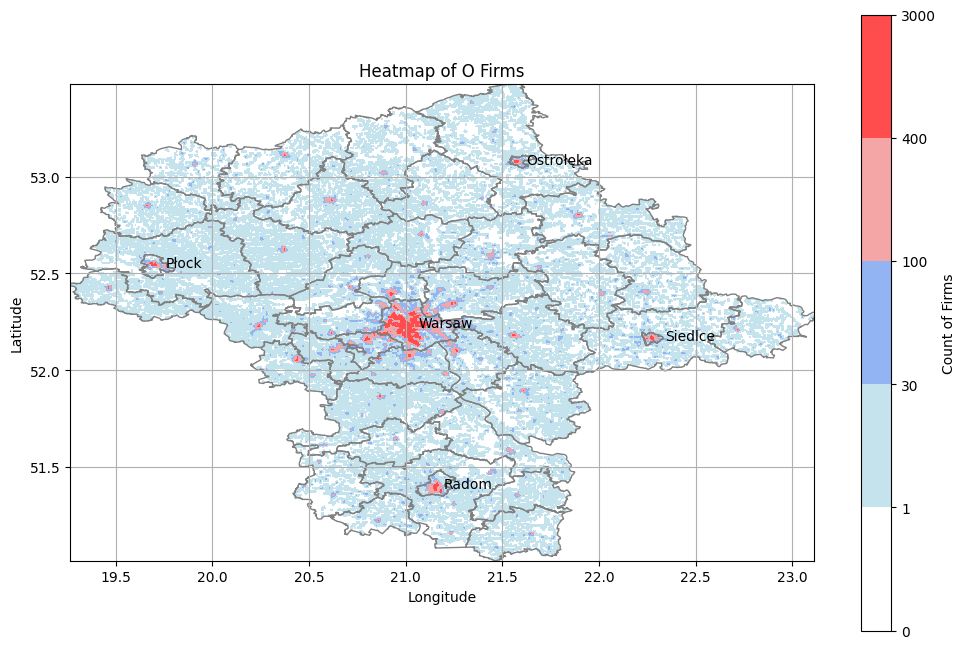

<Figure size 1200x800 with 0 Axes>

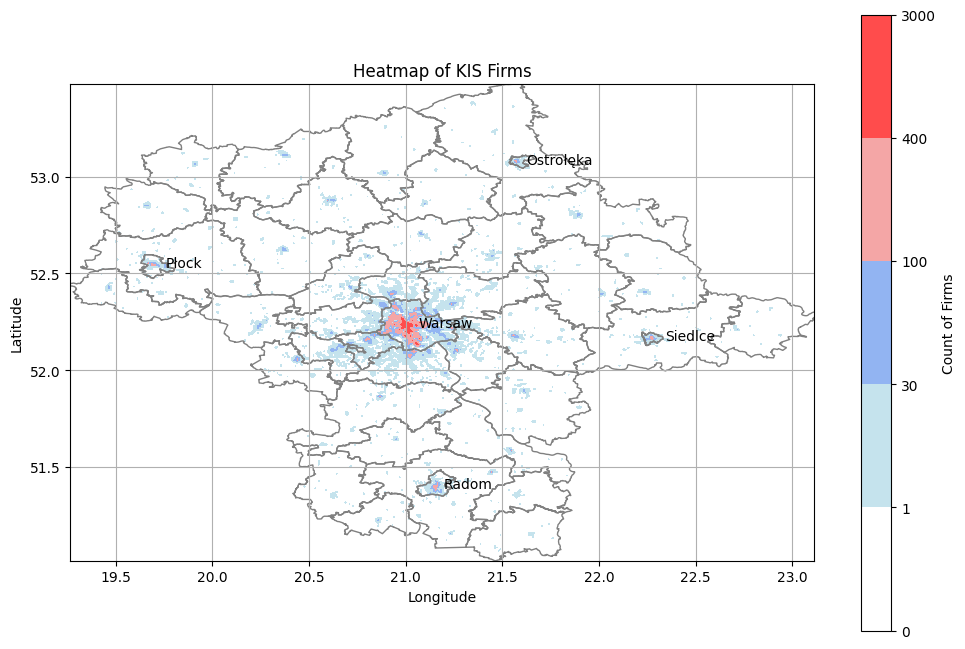

<Figure size 1200x800 with 0 Axes>

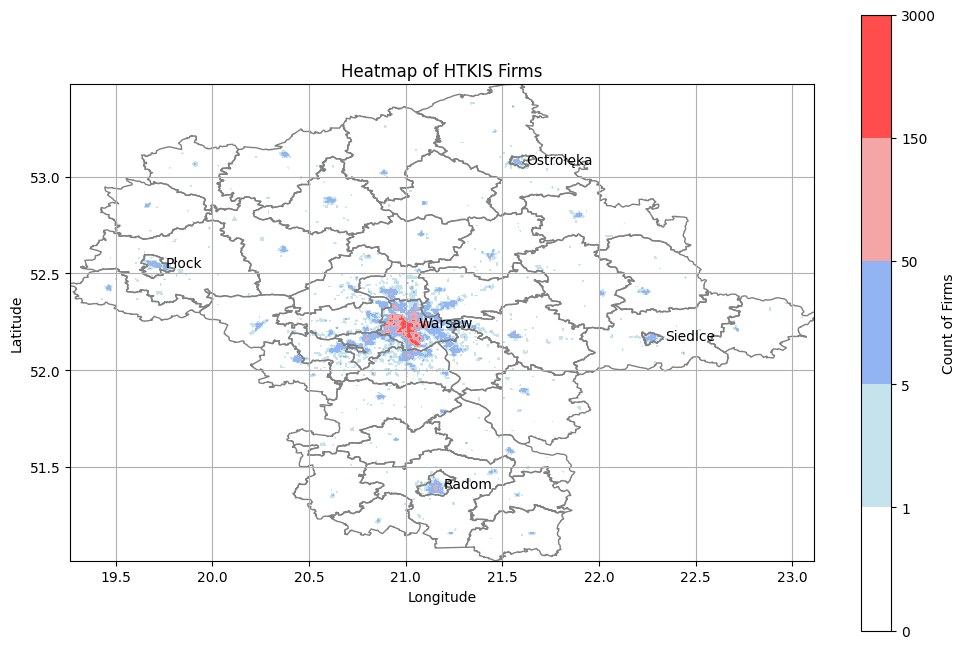

<Figure size 1200x800 with 0 Axes>

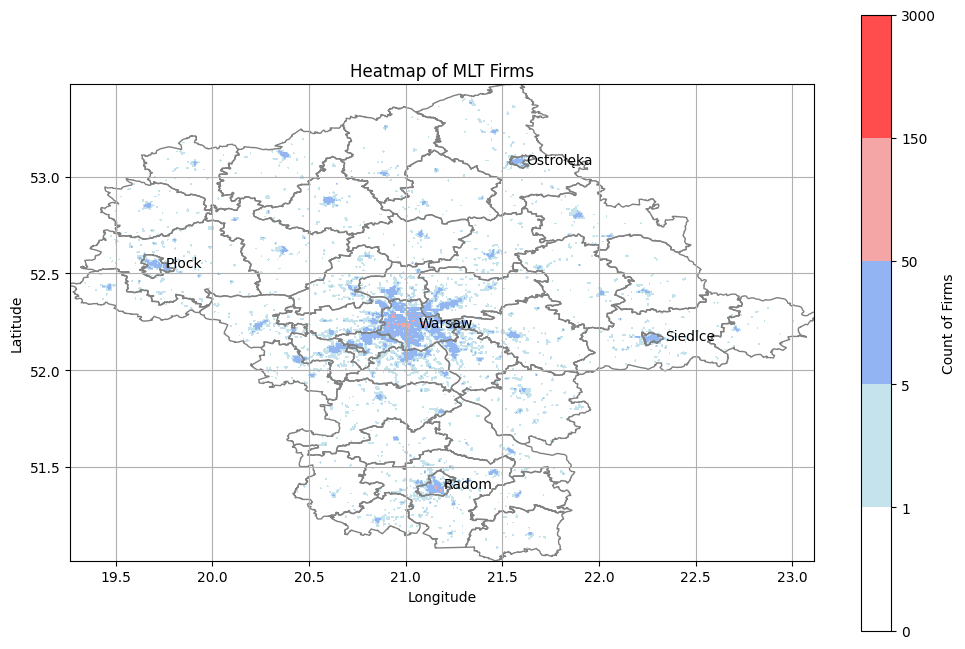

<Figure size 1200x800 with 0 Axes>

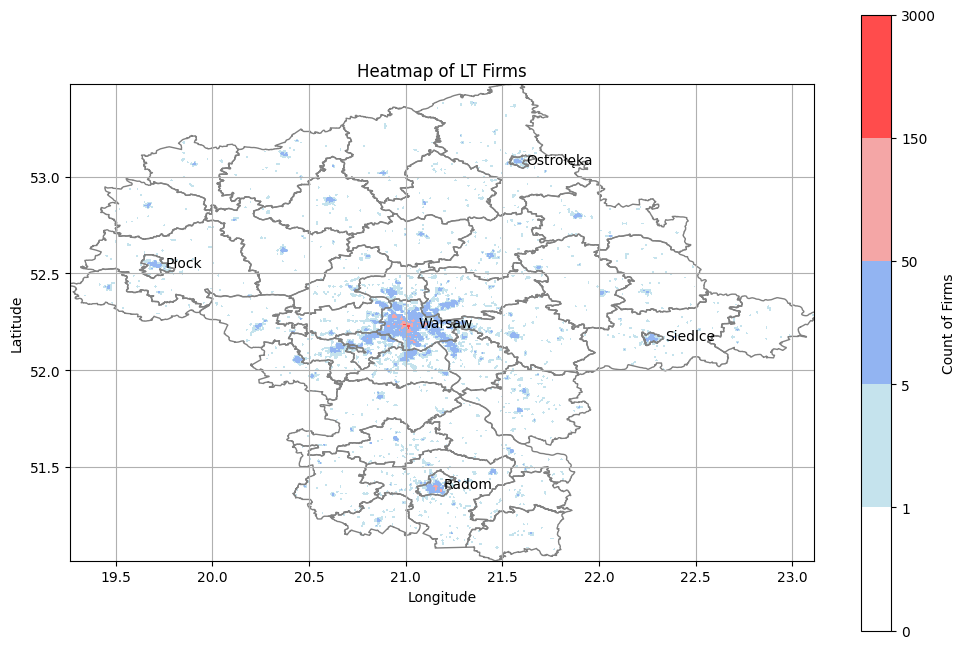

<Figure size 1200x800 with 0 Axes>

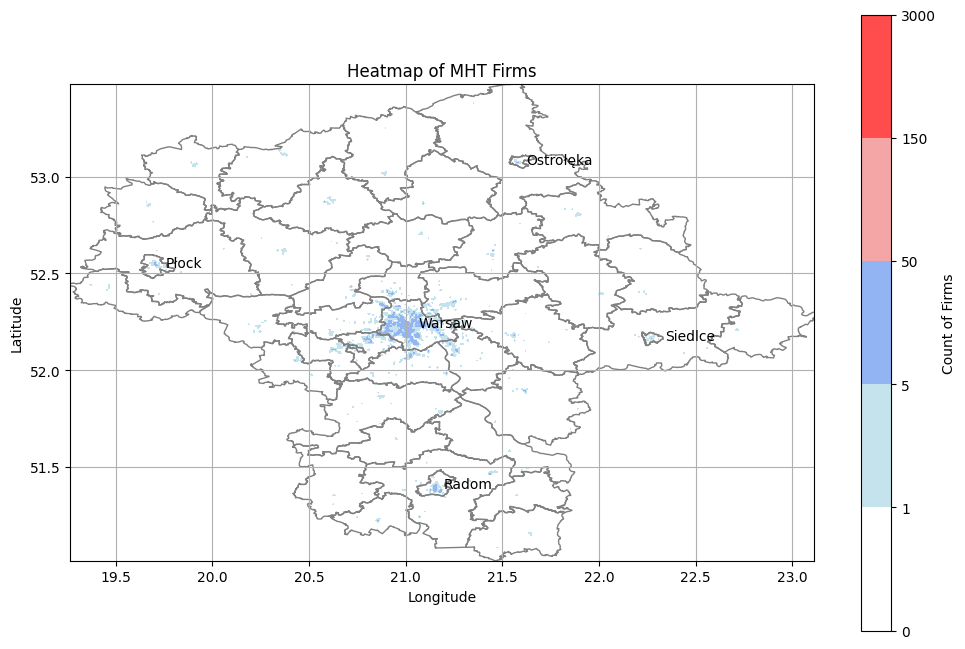

<Figure size 1200x800 with 0 Axes>

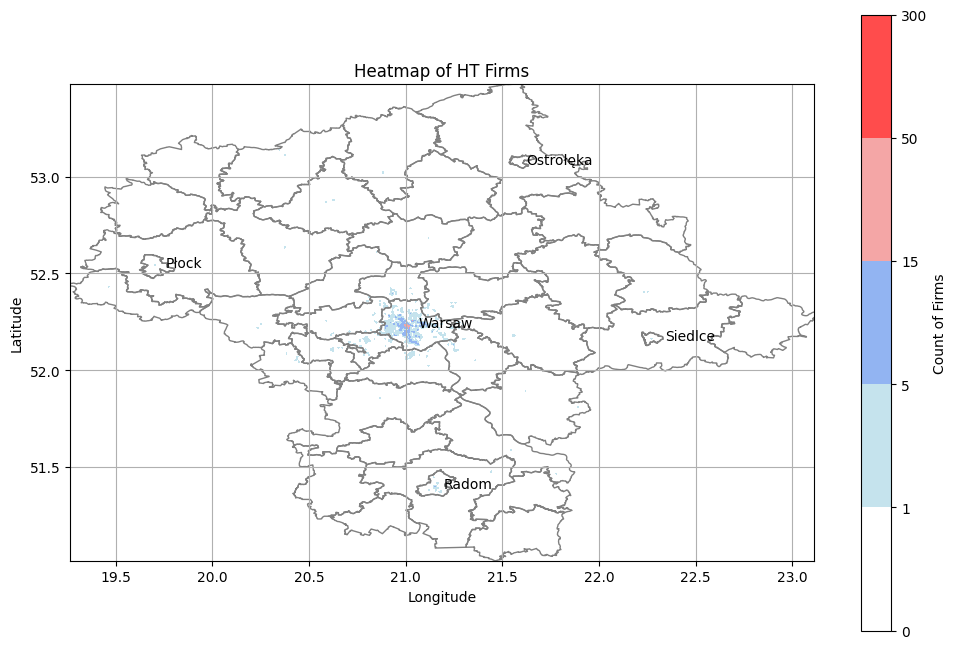

<Figure size 1200x800 with 0 Axes>

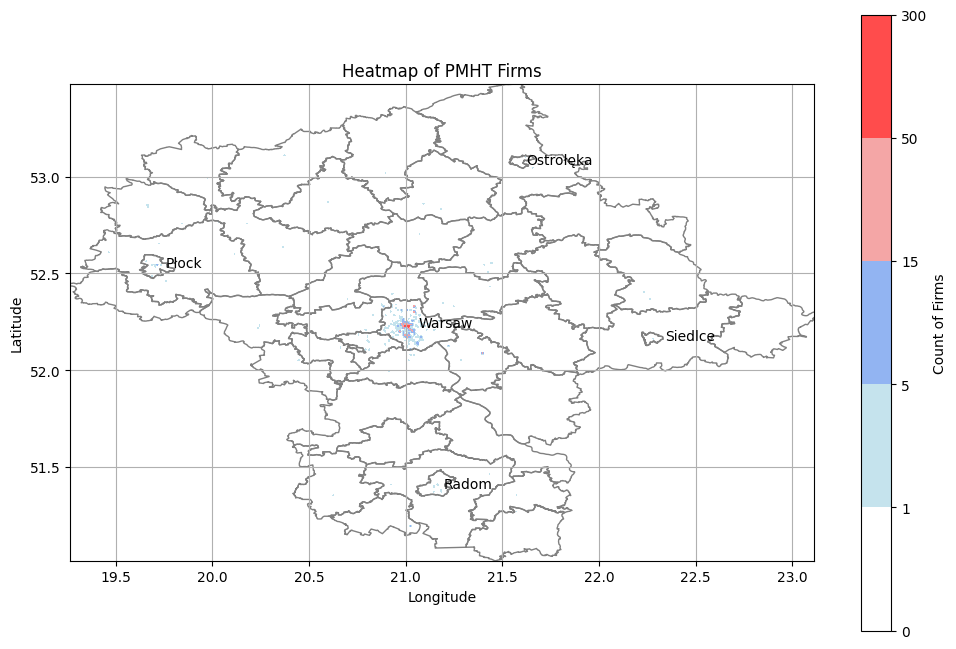

In [116]:

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

min_lon_all, max_lon_all = gdf['lon'].min(), gdf['lon'].max()
min_lat_all, max_lat_all = gdf['lat'].min(), gdf['lat'].max()

def generate_heatmap_for_group(group_name):
    # Filter DataFrame for the specified group
    group_df = gdf[gdf['Group'] == group_name]
    
    # Calculate min and max values for lon and lat for the filtered DataFrame
    min_lon, max_lon = group_df['lon'].min(), group_df['lon'].max()
    min_lat, max_lat = group_df['lat'].min(), group_df['lat'].max()

    # Define grid size (adjust according to your needs)
    grid_size = 0.0093

    
    # Generate grid of lon and lat values
    lons = np.arange(min_lon_all, max_lon_all, grid_size)
    lats = np.arange(min_lat_all, max_lat_all, grid_size)
    
    # Digitize lon and lat values
    group_df['grid_x'] = np.digitize(group_df['lon'], lons)
    group_df['grid_y'] = np.digitize(group_df['lat'], lats)
    
    # Group by grid coordinates and count firms
    grid_counts = group_df.groupby(['grid_x', 'grid_y']).size().reset_index(name='firm_count')
    group_df = group_df.merge(grid_counts, how='left', on=['grid_x', 'grid_y'])


    # Create a copy of the merged DataFrame with a name like gdf_groupname
    globals()[f"gdf_{group_name}"] = group_df.copy()

    # Create heatmap matrix
    heatmap = np.zeros((len(lats), len(lons)))
    
    # Populate heatmap matrix with counts
    for idx, row in grid_counts.iterrows():
        grid_x, grid_y = row['grid_x'] - 1, row['grid_y'] - 1  
        count = row['firm_count']
        heatmap[grid_y, grid_x] = count

    city_lon = [21.017532, 21.14714, 19.70638, 22.29006, 21.5714]
    city_lat = [52.237049, 51.40253, 52.54682, 52.16772, 53.0813]
    city_names = ['Warsaw', 'Radom', 'Płock', 'Siedlce', 'Ostrołęka']

    # Define colors and bounds based on group_name
    colors = ['white', 'lightblue', 'cornflowerblue', 'lightcoral', 'red']
    if group_name in ['HTKIS', 'MLT', 'LT', 'MHT']:
        bounds = [0, 1, 5, 50, 150, 3000]
    elif group_name in ['O', 'KIS']:
        bounds = [0, 1, 30, 100, 400, 3000]
    else:
        bounds = [0, 1, 5, 15, 50, 300]

    cmap = ListedColormap(colors)
    norm = BoundaryNorm(bounds, len(colors))    
    
    # Plot heatmap
    plt.figure(figsize=(12, 8))
    ax = powiaty_maz.plot(figsize=(12, 8), color='none', edgecolor='grey')
    img = ax.imshow(heatmap, cmap=cmap, norm=norm, origin='lower', extent=[min_lon_all, max_lon_all, min_lat_all, max_lat_all], alpha=0.7)

    for city, lon, lat in zip(city_names, city_lon, city_lat):
        plt.annotate(city, xy=(lon, lat), xytext=(7, -2), textcoords='offset points', color='black', fontsize=10)

    plt.colorbar(img, label='Count of Firms')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Heatmap of {group_name} Firms')
    plt.grid(True)
    plt.show()


group_names = ['O', 'KIS', 'HTKIS', 'MLT', 'LT', 'MHT', 'HT', 'PMHT']

dfs = []

for group_name in group_names:
    generate_heatmap_for_group(group_name)
    dfs.append(globals()[f"gdf_{group_name}"])

gdf_counts= pd.concat(dfs, ignore_index=True)

In [117]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [91]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

min_lon_all, max_lon_all = gdf['lon'].min(), gdf['lon'].max()
min_lat_all, max_lat_all = gdf['lat'].min(), gdf['lat'].max()

# Calculate the grid
def create_grid(min_lon, max_lon, min_lat, max_lat):
    # Calculate the length and width of the area in kilometers
    length_km = 111.32 * (max_lon - min_lon)
    width_km = 111.32 * (max_lat - min_lat)

    # Calculate the number of grid cells needed to achieve 1x1km grid cells
    num_cells_x = int(np.ceil(length_km))
    num_cells_y = int(np.ceil(width_km))

    # Calculate the grid size in lon and lat
    grid_size_lon = (max_lon - min_lon) / num_cells_x
    grid_size_lat = (max_lat - min_lat) / num_cells_y

    # Generate grid of lon and lat values
    lons = np.arange(min_lon, max_lon + grid_size_lon, grid_size_lon)
    lats = np.arange(min_lat, max_lat + grid_size_lat, grid_size_lat)

    # Create grid polygons
    polygons = []
    for x in range(len(lons) - 1):
        for y in range(len(lats) - 1):
            lon1, lon2 = lons[x], lons[x + 1]
            lat1, lat2 = lats[y], lats[y + 1]
            polygon = Polygon([(lon1, lat1), (lon1, lat2), (lon2, lat2), (lon2, lat1)])
            polygons.append(polygon)

    # Create GeoDataFrame for grid
    grid_gdf = gpd.GeoDataFrame(geometry=polygons)
    
    return grid_gdf

# Define function to generate heatmap
def count_firms_on_grid(group_df, group_name, grid_gdf):
    # Calculate min and max values for lon and lat for the filtered DataFrame
    min_lon, max_lon = group_df['lon'].min(), group_df['lon'].max()
    min_lat, max_lat = group_df['lat'].min(), group_df['lat'].max()

    # Spatial join to count firms in each grid cell
    grid_with_counts = gpd.sjoin(grid_gdf, group_df, how="left", op='contains')
    grid_counts = grid_with_counts.groupby(grid_with_counts.index)['Group'].count().reset_index(name='firm_count')

    # Merge counts with grid GeoDataFrame
    grid_gdf_counted = grid_gdf.merge(grid_counts, left_index=True, right_on='index', how='left')
    grid_gdf_counted = grid_gdf_counted.set_index('index')

    return grid_gdf_counted

# Create an empty DataFrame to store the counts
counts_df = pd.DataFrame()


# Pre-calculate the grid
grid_gdf = create_grid(min_lon_all, max_lon_all, min_lat_all, max_lat_all)

group_names = ['O', 'KIS', 'HTKIS', 'MLT', 'LT', 'MHT', 'HT', 'PMHT']

# Assuming group_names is defined elsewhere in your code
for group_name in group_names:
    group_df = gdf[gdf['Group'] == group_name]
    counted_df = count_firms_on_grid(group_df, group_name, grid_gdf)
    counts_df[group_name] = counted_df['firm_count']


grid_counts_final = grid_gdf.merge(counts_df, left_index=True, right_on='index', how='left')

In [104]:
grid_counts_final

,geometry,O,KIS,HTKIS,MLT,LT,MHT,HT,PMHT
index,,,,,,,,,
0,"POLYGON ((19.26448 51.01501, 19.26448 51.02397...",0,0,0,0,0,0,0,0
1,"POLYGON ((19.26448 51.02397, 19.26448 51.03292...",0,0,0,0,0,0,0,0
2,"POLYGON ((19.26448 51.03292, 19.26448 51.04188...",0,0,0,0,0,0,0,0
3,"POLYGON ((19.26448 51.04188, 19.26448 51.05083...",0,0,0,0,0,0,0,0
4,"POLYGON ((19.26448 51.05083, 19.26448 51.05979...",0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
117970,"POLYGON ((23.10261 53.43301, 23.10261 53.44197...",0,0,0,0,0,0,0,0
117971,"POLYGON ((23.10261 53.44197, 23.10261 53.45092...",0,0,0,0,0,0,0,0
117972,"POLYGON ((23.10261 53.45092, 23.10261 53.45988...",0,0,0,0,0,0,0,0


In [107]:
grid_counts_powiaty = gpd.sjoin(grid_counts_final, powiaty_maz, how='inner', op='within').reset_index()

In [108]:
grid_counts_powiaty

,index,geometry,O,KIS,HTKIS,MLT,LT,MHT,HT,PMHT,index_right,JPT_NAZWA_
0,434,"POLYGON ((19.27344 52.43894, 19.27344 52.44790...",3,0,0,0,0,0,0,0,62,powiat gostyniński
1,709,"POLYGON ((19.28241 52.43894, 19.28241 52.44790...",1,0,0,0,0,0,0,0,62,powiat gostyniński
2,979,"POLYGON ((19.29138 52.39417, 19.29138 52.40312...",6,0,0,0,0,0,0,0,62,powiat gostyniński
3,983,"POLYGON ((19.29138 52.42999, 19.29138 52.43894...",5,0,0,0,0,0,0,0,62,powiat gostyniński
4,1254,"POLYGON ((19.30035 52.39417, 19.30035 52.40312...",5,0,0,0,0,0,0,0,62,powiat gostyniński
...,...,...,...,...,...,...,...,...,...,...,...,...
52038,117564,"POLYGON ((23.09364 52.25983, 23.09364 52.26879...",1,0,0,0,0,0,0,0,60,powiat łosicki
52039,117565,"POLYGON ((23.09364 52.26879, 23.09364 52.27774...",30,0,0,0,1,0,0,0,60,powiat łosicki
52040,117566,"POLYGON ((23.09364 52.27774, 23.09364 52.28670...",0,0,0,0,0,0,0,0,60,powiat łosicki
52041,117841,"POLYGON ((23.10261 52.27774, 23.10261 52.28670...",18,0,0,0,2,0,0,0,60,powiat łosicki


In [ ]:
def generate_heatmap_for_group(group_df, group_name):
    
    grid_gdf_counted = count_firms_on_grid(group_df, group_name, grid_gdf)

    # Define colors and bounds based on group_name
    colors = ['white', 'lightblue', 'cornflowerblue', 'lightcoral', 'red']
    if group_name in ['HTKIS', 'MLT', 'LT', 'MHT']:
        bounds = [0, 1, 5, 50, 150, 3000]
    elif group_name in ['O', 'KIS']:
        bounds = [0, 1, 30, 100, 400, 3000]
    else:
        bounds = [0, 1, 5, 15, 50, 300]

    cmap = ListedColormap(colors)
    norm = BoundaryNorm(bounds, len(colors))

    # Plot heatmap
    fig, ax = plt.subplots(figsize=(12, 8))
    grid_gdf_counted.plot(column='firm_count', cmap=cmap, norm=norm, linewidth=0, ax=ax, edgecolor='grey', legend=True)
    
    # Plot Mazovian boundaries
    powiaty_maz.plot(ax=ax, facecolor='none', edgecolor='grey', linewidth=0.6)
    # Plot cities
    city_lon = [21.017532, 21.14714, 19.70638, 22.29006, 21.5714]
    city_lat = [52.237049, 51.40253, 52.54682, 52.16772, 53.0813]
    city_names = ['Warsaw', 'Radom', 'Płock', 'Siedlce', 'Ostrołęka']
    for city, lon, lat in zip(city_names, city_lon, city_lat):
        plt.annotate(city, xy=(lon, lat), xytext=(7, -2), textcoords='offset points', color='black', fontsize=10)

    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Heatmap of {group_name} Firms')
    plt.grid(True)
    plt.show()

# Assuming group_names is defined elsewhere in your code
for group_name in group_names:
    group_df = gdf[gdf['Group'] == group_name]
    generate_heatmap_for_group(group_df, group_name)

In [ ]:
# Aggregate firm counts for each group within each cell
grid_data_aggregated = gdf_counts.groupby(['grid_x', 'grid_y', 'Group'])['firm_count'].first().reset_index()

# Pivot the aggregated DataFrame to create separate columns for firm counts for each group in each cell
grid_data_pivoted = grid_data_aggregated.pivot_table(index=['grid_x', 'grid_y'], columns='Group', values='firm_count').reset_index()

# Fill NA with 0
grid_data_pivoted = grid_data_pivoted.fillna(0)

# Merge grid_data_pivoted with gdf_coutns
grid_data = gdf_counts.merge(grid_data_pivoted, on=['grid_x', 'grid_y'], how='left')

# Drop duplicated grid cells
grid_data = grid_data.drop_duplicates(subset=['grid_x', 'grid_y'])

# Sort the DataFrame by 'grid_x' and 'grid_y'
grid_data = grid_data.sort_values(['grid_x', 'grid_y'])

# Add a new column 'grid_xy' with the numbering of grid cells
grid_data['grid_xy'] = np.arange(1, grid_data.shape[0] + 1)

In [ ]:
grid_counts = grid_data.iloc[:, 64:].reset_index()

In [ ]:
grid_counts

In [ ]:
groups = ['HTKIS', 'MLT', 'LT', 'MHT', 'O', 'KIS', 'HT']

In [ ]:
for group in groups:
    group_count = grid_counts[group].sum()
    grid_counts[f'cell_{group}_to_{group}_total'] = grid_counts[group] / group_count 

In [ ]:
for group in groups:
    grid_counts[f'cell_{group}_to_cell_total'] = grid_counts[group] / grid_counts['firm_count']

In [ ]:
import matplotlib.pyplot as plt

# Calculate the maximum values for each column
max_values = grid_counts.iloc[:, 11:].max().sort_values(ascending=False)

# Plot the maximum values
plt.figure(figsize=(10, 6))
max_values.plot(kind='bar', color='skyblue')
plt.xlabel('Group')
plt.ylabel('Max Firm Count')
plt.title('Maximum Firm Count for Each Group')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [156]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

min_lon_all, max_lon_all = gdf['lon'].min(), gdf['lon'].max()
min_lat_all, max_lat_all = gdf['lat'].min(), gdf['lat'].max()

# Calculate the grid
def create_grid(min_lon, max_lon, min_lat, max_lat):
    avg_lat = (min_lat + max_lat) / 2
    
    # Calculate the length and width of the area in kilometers
    length_km =  111.32 * (max_lon - min_lon) * np.cos(np.radians(avg_lat))
    width_km = 111.32 * (max_lat - min_lat)

    # Calculate the number of grid cells needed to achieve 1x1km grid cells
    num_cells_x = int(np.ceil(length_km))
    num_cells_y = int(np.ceil(width_km))

    # Calculate the grid size in lon and lat
    grid_size_lon = (max_lon - min_lon) / num_cells_x
    grid_size_lat = (max_lat - min_lat) / num_cells_y

    # Generate grid of lon and lat values
    lons = np.arange(min_lon, max_lon + grid_size_lon, grid_size_lon)
    lats = np.arange(min_lat, max_lat + grid_size_lat, grid_size_lat)

    # Create grid polygons
    polygons = []
    for x in range(len(lons) - 1):
        for y in range(len(lats) - 1):
            lon1, lon2 = lons[x], lons[x + 1]
            lat1, lat2 = lats[y], lats[y + 1]
            polygon = Polygon([(lon1, lat1), (lon1, lat2), (lon2, lat2), (lon2, lat1)])
            polygons.append(polygon)

    # Create GeoDataFrame for grid
    grid_gdf = gpd.GeoDataFrame(geometry=polygons)
    
    return grid_gdf

# Define function to generate heatmap
def count_firms_on_grid(group_df, group_name, grid_gdf):
    # Calculate min and max values for lon and lat for the filtered DataFrame
    min_lon, max_lon = group_df['lon'].min(), group_df['lon'].max()
    min_lat, max_lat = group_df['lat'].min(), group_df['lat'].max()

    # Spatial join to count firms in each grid cell
    grid_with_counts = gpd.sjoin(grid_gdf, group_df, how="left", op='contains')
    grid_counts = grid_with_counts.groupby(grid_with_counts.index)['Group'].count().reset_index(name='firm_count')

    # Merge counts with grid GeoDataFrame
    grid_gdf_counted = grid_gdf.merge(grid_counts, left_index=True, right_on='index', how='left')
    grid_gdf_counted = grid_gdf_counted.set_index('index')

    return grid_gdf_counted

# Create an empty DataFrame to store the counts
counts_df = pd.DataFrame()


# Pre-calculate the grid
grid_gdf = create_grid(min_lon_all, max_lon_all, min_lat_all, max_lat_all)

group_names = ['O', 'KIS', 'HTKIS', 'MLT', 'LT', 'MHT', 'HT', 'PMHT']

# Assuming group_names is defined elsewhere in your code
for group_name in group_names:
    group_df = gdf[gdf['Group'] == group_name]
    counted_df = count_firms_on_grid(group_df, group_name, grid_gdf)
    counts_df[group_name] = counted_df['firm_count']


grid_counts_final = grid_gdf.merge(counts_df, left_index=True, right_on='index', how='left')

In [157]:
grid_counts_powiaty = gpd.sjoin(grid_counts_final, powiaty_maz, how='inner', op='within').reset_index()
grid_counts_powiaty

,index,geometry,O,KIS,HTKIS,MLT,LT,MHT,HT,PMHT,index_right,JPT_NAZWA_
0,352,"POLYGON ((19.32276 52.37132, 19.32276 52.38917...",30,0,0,1,2,0,0,0,62,powiat gostyniński
1,353,"POLYGON ((19.32276 52.38917, 19.32276 52.40702...",32,0,0,1,0,0,0,0,62,powiat gostyniński
2,354,"POLYGON ((19.32276 52.40702, 19.32276 52.42486...",23,0,0,0,0,0,0,0,62,powiat gostyniński
3,355,"POLYGON ((19.32276 52.42486, 19.32276 52.44271...",37,0,0,0,0,0,0,0,62,powiat gostyniński
4,489,"POLYGON ((19.35191 52.35348, 19.35191 52.37132...",11,0,0,0,0,0,0,0,62,powiat gostyniński
...,...,...,...,...,...,...,...,...,...,...,...,...
6877,17735,"POLYGON ((22.99500 52.28209, 22.99500 52.29994...",0,0,0,0,0,0,0,0,60,powiat łosicki
6878,17736,"POLYGON ((22.99500 52.29994, 22.99500 52.31778...",0,0,0,0,0,0,0,0,60,powiat łosicki
6879,17871,"POLYGON ((23.02415 52.24640, 23.02415 52.26425...",0,0,0,0,0,0,0,0,60,powiat łosicki
6880,17872,"POLYGON ((23.02415 52.26425, 23.02415 52.28209...",16,0,0,0,0,0,0,0,60,powiat łosicki


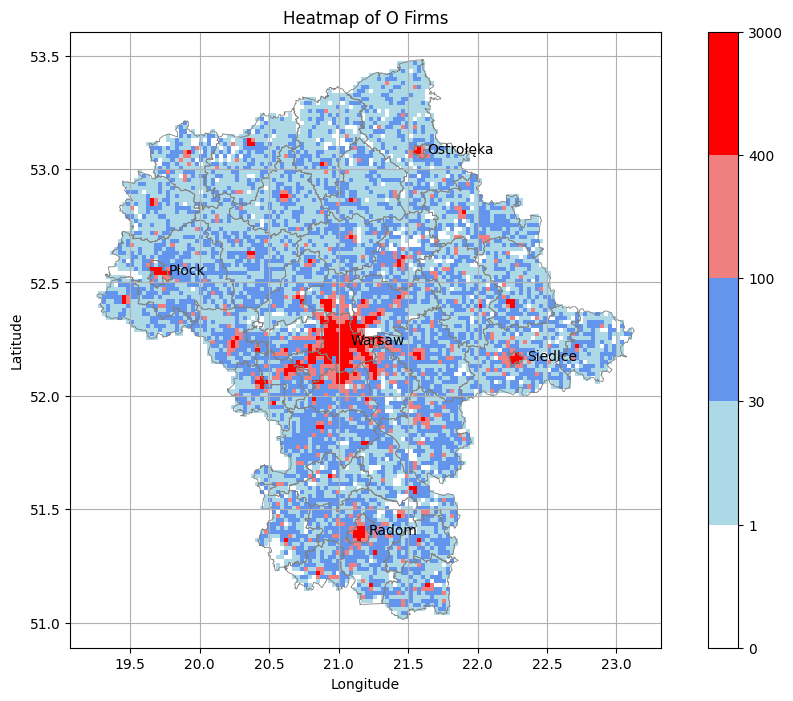

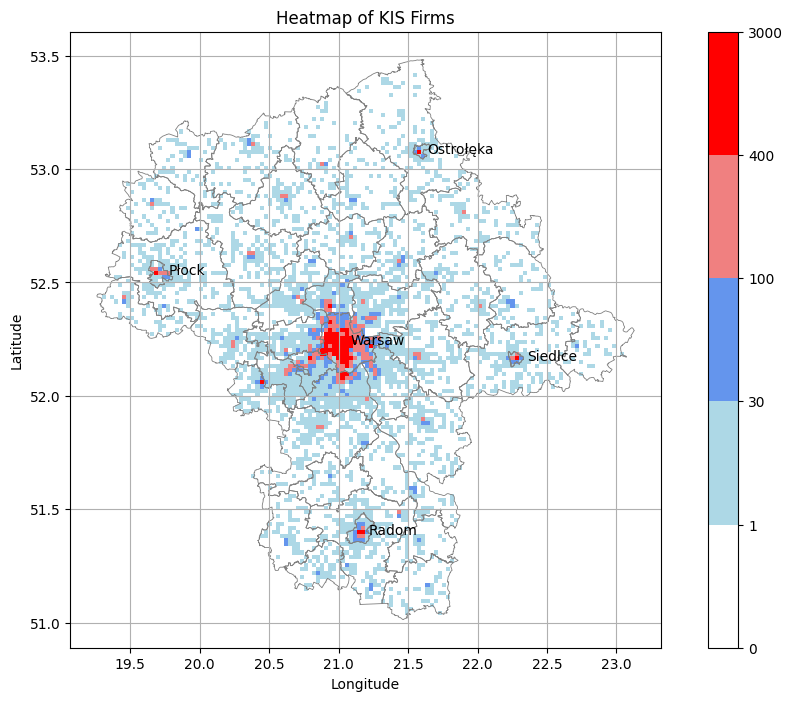

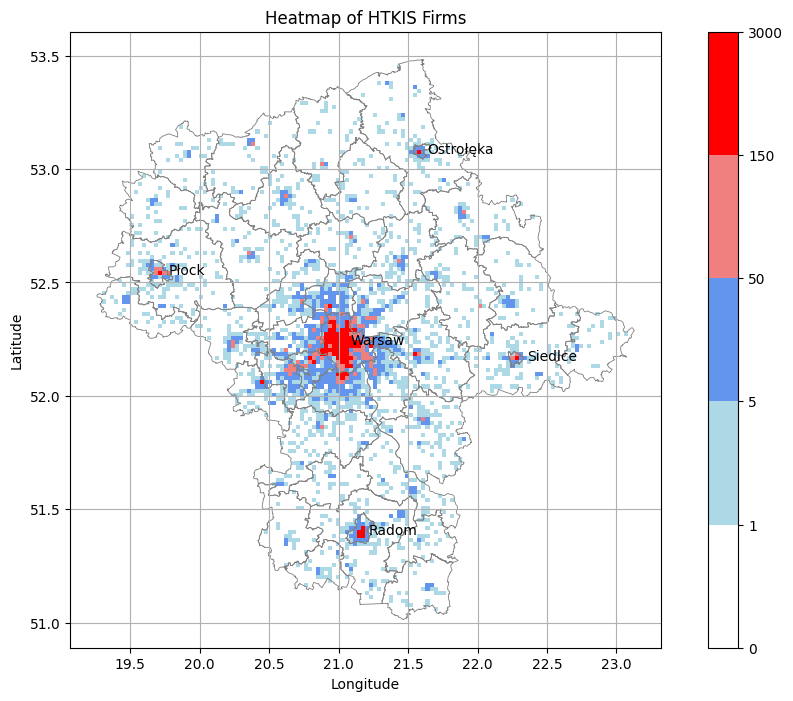

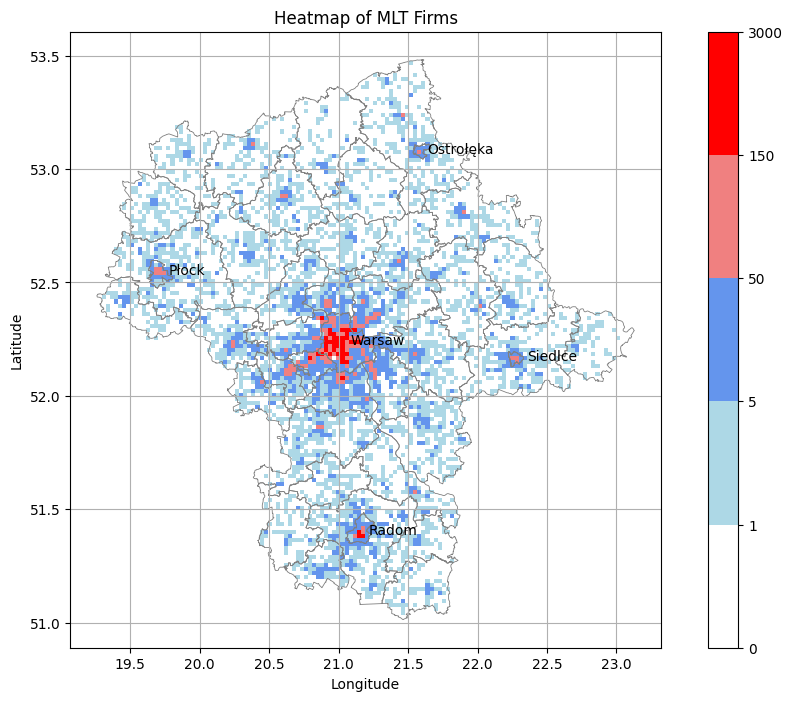

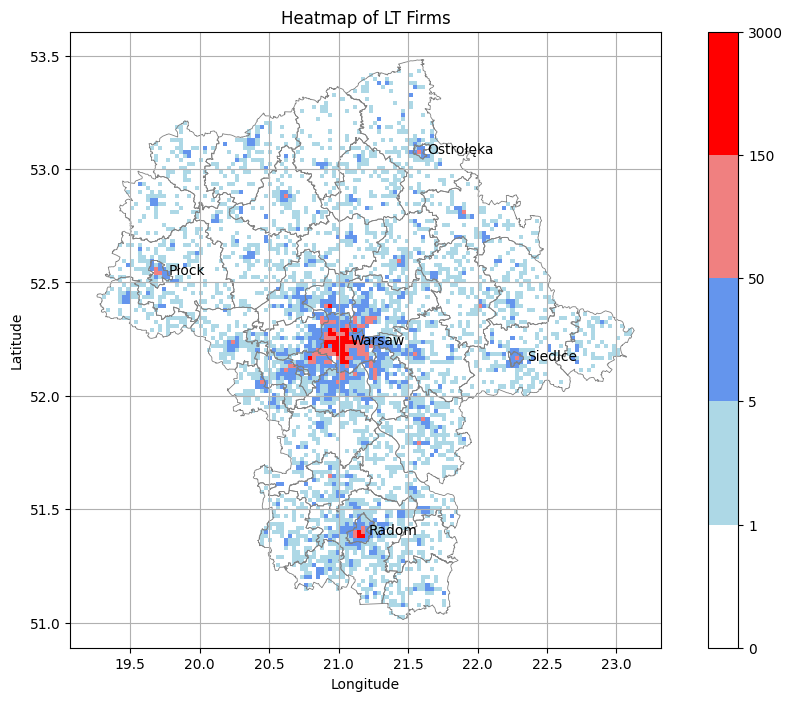

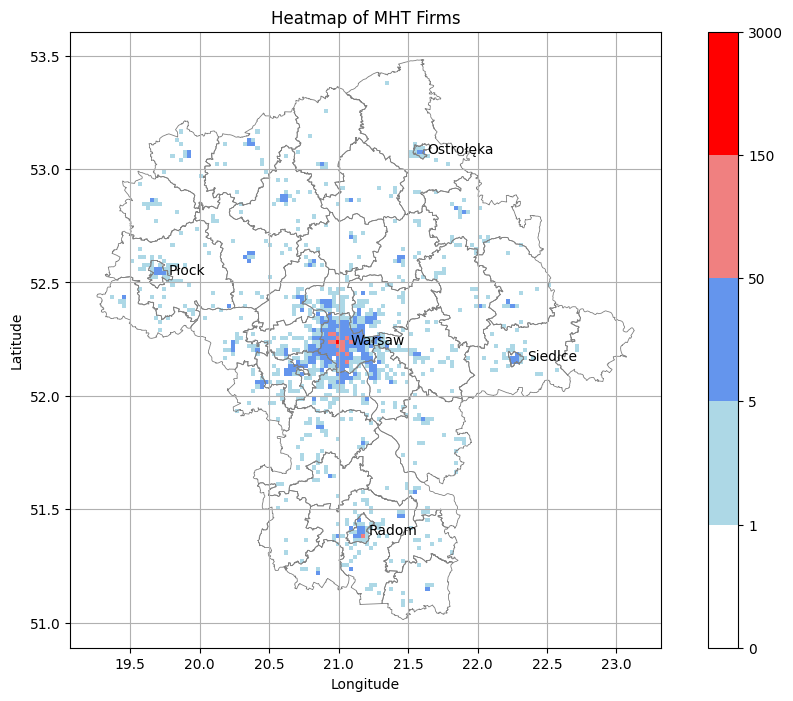

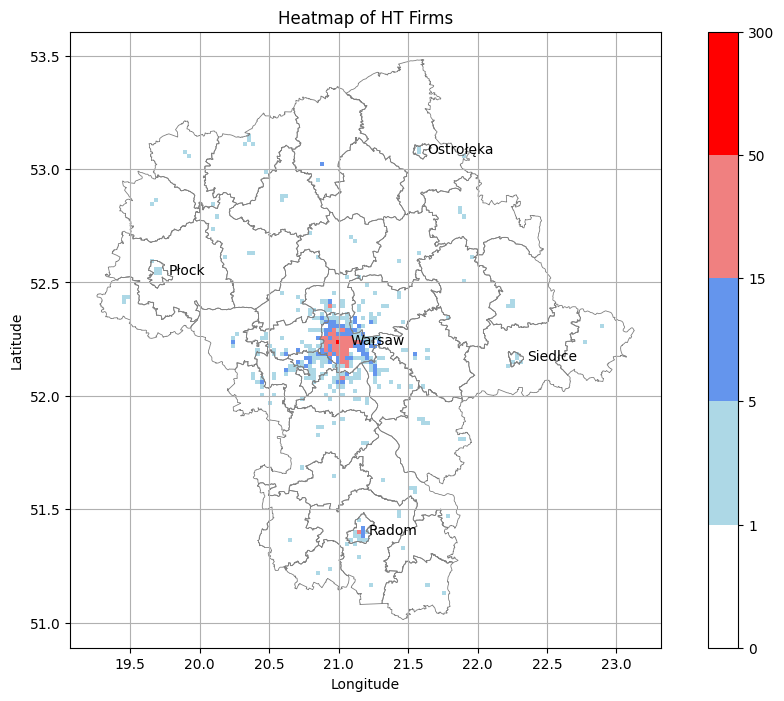

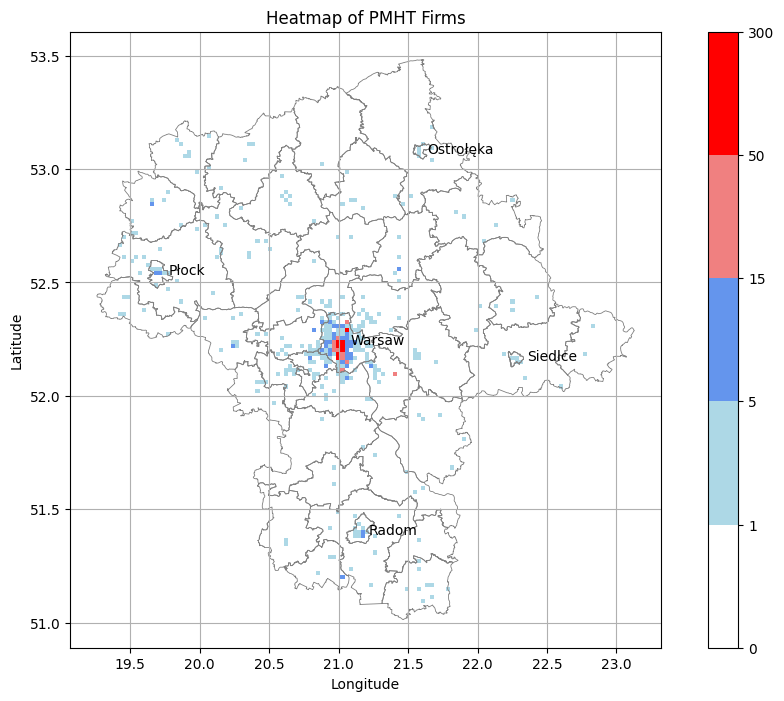

In [158]:
def generate_heatmap_for_group(group_df, group_name):
    
    grid_gdf_counted = count_firms_on_grid(group_df, group_name, grid_gdf)

    # Define colors and bounds based on group_name
    colors = ['white', 'lightblue', 'cornflowerblue', 'lightcoral', 'red']
    if group_name in ['HTKIS', 'MLT', 'LT', 'MHT']:
        bounds = [0, 1, 5, 50, 150, 3000]
    elif group_name in ['O', 'KIS']:
        bounds = [0, 1, 30, 100, 400, 3000]
    else:
        bounds = [0, 1, 5, 15, 50, 300]

    cmap = ListedColormap(colors)
    norm = BoundaryNorm(bounds, len(colors))

    # Plot heatmap
    fig, ax = plt.subplots(figsize=(12, 8))
    grid_gdf_counted.plot(column='firm_count', cmap=cmap, norm=norm, linewidth=0, ax=ax, edgecolor='grey', legend=True)
    
    # Plot Mazovian boundaries
    powiaty_maz.plot(ax=ax, facecolor='none', edgecolor='grey', linewidth=0.6)
    # Plot cities
    city_lon = [21.017532, 21.14714, 19.70638, 22.29006, 21.5714]
    city_lat = [52.237049, 51.40253, 52.54682, 52.16772, 53.0813]
    city_names = ['Warsaw', 'Radom', 'Płock', 'Siedlce', 'Ostrołęka']
    for city, lon, lat in zip(city_names, city_lon, city_lat):
        plt.annotate(city, xy=(lon, lat), xytext=(7, -2), textcoords='offset points', color='black', fontsize=10)

    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Heatmap of {group_name} Firms')
    plt.grid(True)
    plt.show()

# Assuming group_names is defined elsewhere in your code
for group_name in group_names:
    group_df = gdf[gdf['Group'] == group_name]
    generate_heatmap_for_group(group_df, group_name)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

predictors = ['locHH', 'lon', 'lat', 'empl', 'sharesEMPL2', 'locPdens', 'locBIG', 'locAggTOTAL', 'locHightech', 'locLQ', 'dist_core_10', 
              'dist_core_25', 'dist_core_50', 'dist_midsize_10', 'dist_midsize_25', 'dist_midsize_50', 'dist_regional_10', 'dist_regional_25', 
              'dist_regional_50', 'dist_localbig_10', 'dist_localbig_25', 'dist_localbig_50', 'dist_localsmall_10', 'dist_localsmall_25', 'dist_localsmall_50']

y = gdf['if_hightech']
X = gdf[predictors]


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the Random Forest Classifier model
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Evaluate the model
y_pred = rf_classifier.predict(X_test)
print(classification_report(y_test, y_pred))


In [ ]:
# Get feature importances from the trained model
feature_importances = rf_classifier.feature_importances_

# Create a DataFrame to store feature names and their importances
feature_importance_df = pd.DataFrame({'Feature': predictors, 'Importance': feature_importances})

# Sort the DataFrame by importance values in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print the top N most important features
print("Top 10 Most Important Features:")
print(feature_importance_df.head(10))

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Importance'][:10])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Most Important Features')
plt.gca().invert_yaxis()  # Invert y-axis to display the most important features at the top
plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = rf_classifier.predict(X_test)
confusion_matrix(y_test, y_pred)

In [ ]:
import scikit-plot as skplt


skplt.metrics.plot_confusion_matrix(y_train, y_pred)


In [ ]:
import geopandas as gpd
from pysal.lib import weights
from pysal.explore import esda
import matplotlib.pyplot as plt
from splot.esda import plot_moran


group_names = gdf_counts['Group'].unique()

for group_name in group_names:

    group_df = gdf_counts[gdf_counts['Group'] == group_name]
    w = weights.Queen.from_dataframe(group_df)
    moran = esda.Moran(group_df['firm_count'], w)
    
    print(f"\nMoran's I for {group_name}:")
    print("Moran's I:", moran.I)
    print("Moran's I p-value:", moran.p_sim)

Heatmaps of all the groups for grid 1, 2, 5km

In [ ]:
def generate_heatmap_for_group(group_name, grid_size, ax):
    # Filter DataFrame for the specified group
    group_df = gdf[gdf['Group'] == group_name]
    
    # Calculate min and max values for lon and lat for the filtered DataFrame
    min_lon, max_lon = group_df['lon'].min(), group_df['lon'].max()
    min_lat, max_lat = group_df['lat'].min(), group_df['lat'].max()
    
    
    # Generate grid of lon and lat values
    lons = np.arange(min_lon, max_lon, grid_size)
    lats = np.arange(min_lat, max_lat, grid_size)
    
    # Digitize lon and lat values
    group_df['grid_x'] = np.digitize(group_df['lon'], lons)
    group_df['grid_y'] = np.digitize(group_df['lat'], lats)
    
    # Group by grid coordinates and count firms
    grid_counts = group_df.groupby(['grid_x', 'grid_y']).size().reset_index(name='firm_count')
    group_df = group_df.merge(grid_counts, how='left', on=['grid_x', 'grid_y'])

    # Create a copy of the merged DataFrame with a name like gdf_groupname_gridsize
    globals()[f"gdf_{group_name}_{int(grid_size*1000)}m"] = group_df.copy()

    # Create heatmap matrix
    heatmap = np.zeros((len(lats), len(lons)))
    
    # Populate heatmap matrix with counts
    for idx, row in grid_counts.iterrows():
        grid_x, grid_y = row['grid_x'] - 1, row['grid_y'] - 1  
        count = row['firm_count']
        heatmap[grid_y, grid_x] = count

    # Define colors and bounds based on group_name
    colors = ['white', 'lightblue', 'cornflowerblue', 'lightcoral', 'red']
    if group_name in ['HTKIS', 'MLT', 'LT', 'MHT', 'PMHT']:
        bounds = [0, 1, 5, 50, 150, 3000]
    elif group_name in ['O', 'KIS']:
        bounds = [0, 1, 30, 100, 400, 3000]
    else:
        bounds = [0, 1, 5, 15, 50, 300]

    cmap = ListedColormap(colors)
    norm = BoundaryNorm(bounds, len(colors))    
    
    # Plot heatmap
    img = ax.imshow(heatmap, cmap=cmap, norm=norm, origin='lower', extent=[min_lon, max_lon, min_lat, max_lat], alpha=0.7)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'Firm Count Heatmap of {group_name} (Grid Size: {int(grid_size*1000)}m)')
    ax.grid(True)
    plt.colorbar(img, ax=ax, label='Firm Count')


# Define grid configurations
grid_sizes = [0.01182, 0.02365, 0.05912]  # Grid sizes in degrees (1km, 2km, and 5km)

# Create subplots for each group with different grid configurations
fig, axes = plt.subplots(len(group_names), len(grid_sizes), figsize=(40,40))

# Generate heatmap for each group with different grid configurations
for i, group_name in enumerate(group_names):
    for j, grid_size in enumerate(grid_sizes):
        ax = axes[i, j]
        generate_heatmap_for_group(group_name, grid_size, ax)

plt.tight_layout()
plt.show()
